# Import Libraries

In [1]:
from secml.data.loader import CDataLoaderMNIST
from secml.data.splitter import CTrainTestSplit
import torch
import torch.nn as nn
import torch.optim as optim
from secml.ml.features import CNormalizerMinMax
from secml.data.splitter import CTrainTestSplit
from secml.ml.peval.metrics import CMetricAccuracy
import numpy as np
from secml.array import CArray
from secml.data import CDataset
from secml.adv.attacks.evasion import CFoolboxPGDLinf
from secml.ml.classifiers import CClassifierPyTorch
import copy
from secml.adv.attacks.evasion import CFoolboxFGM
from sklearn.ensemble import IsolationForest
import time
from sklearn.decomposition import PCA

2025-12-18 21:57:59,685 - py.warnings - WARNING - c:\Users\CONG\Anacoda\envs\SecMl25F\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(



# Load MNIST dataset

In [2]:
from secml.data.loader import CDataLoaderMNIST

loader = CDataLoaderMNIST()
train_ds = loader.load('training')
test_ds = loader.load('testing')

# Normalize data

In [3]:
train_ds.X /= 255.0
test_ds.X /= 255.0

# Train-test splits 

In [4]:
full_ds = train_ds.append(test_ds)
splitter = CTrainTestSplit(train_size=0.7, random_state=42)
train_ds, test_ds = splitter.split(full_ds)

# Train-validation splits 

In [5]:
splitter_val = CTrainTestSplit(train_size=0.8, random_state=1)

tr_ds, val_ds = splitter_val.split(train_ds)

print("Train:", tr_ds.num_samples)
print("Validation:", val_ds.num_samples)


Train: 39200
Validation: 9800


# Define CNN model

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Train baseline (clean) model

In [7]:
cnn = SimpleCNN()

classifier = CClassifierPyTorch(
    model=cnn,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(cnn.parameters(), lr=0.001),
    input_shape=(1, 28, 28),
    epochs=1,
    batch_size=128,
    random_state=0
)

In [8]:
classifier.fit(tr_ds.X, tr_ds.Y)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

# Evaluate clean model accuracy

In [9]:
metric = CMetricAccuracy()

y_pred = classifier.predict(test_ds.X)
accuracy = metric.performance_score(test_ds.Y, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9665238095238096


# Confusion matrix

In [10]:
from secml.ml.peval.metrics import CMetricConfusionMatrix

cm_metric = CMetricConfusionMatrix()
cm = cm_metric.performance_score(test_ds.Y, y_pred)
print(cm)


CArray([[2028    1    9 ...    3   10    2]
 [   0 2317   15 ...    4   14    0]
 [   1   10 2067 ...   17   26    2]
 ...
 [   1    4   24 ... 2200    5    4]
 [   7    6    4 ...    7 1938    4]
 [  10    8    1 ...   39   31 1966]])


# Label-flipping attacks

In [11]:
poisoning_rate = 0.10
np.random.seed(0)

In [12]:
poisoned_tr_ds = tr_ds.deepcopy()

n_samples = poisoned_tr_ds.num_samples
n_poison = int(poisoning_rate * n_samples)

print("Total training samples:", n_samples)
print("Poisoned samples:", n_poison)

Total training samples: 39200
Poisoned samples: 3920


In [13]:
poison_idx = CArray(
    np.random.choice(n_samples, n_poison, replace=False)
)

In [14]:
original_labels = poisoned_tr_ds.Y[poison_idx].tondarray()
new_labels = []
for y in original_labels:
    possible_labels = list(set(range(10)) - {int(y)})
    new_labels.append(np.random.choice(possible_labels))
poisoned_tr_ds.Y[poison_idx] = CArray(new_labels)

# Retrain model on poisoned dataset

In [15]:
cnn_poisoned = SimpleCNN()

poisoned_clf = CClassifierPyTorch(
    model=cnn_poisoned,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(cnn_poisoned.parameters(), lr=0.001),
    input_shape=(1, 28, 28),
    epochs=1,
    batch_size=128,
    random_state=0
)

# Evaluate poisoned model on clean set

In [16]:
metric = CMetricAccuracy()

best_val_acc = 0
best_state = None
patience = 3
counter = 0
max_epochs = 20

for epoch in range(max_epochs):
    print(f"Epoch {epoch+1}")

    poisoned_clf.fit(poisoned_tr_ds.X, poisoned_tr_ds.Y)

    y_val_pred = poisoned_clf.predict(val_ds.X)
    val_acc = metric.performance_score(val_ds.Y, y_val_pred)

    print("Validation accuracy:", val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(poisoned_clf.model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

poisoned_clf.model.load_state_dict(best_state)

Epoch 1
Validation accuracy: 0.9704081632653061
Epoch 2
Validation accuracy: 0.9776530612244898
Epoch 3
Validation accuracy: 0.981938775510204
Epoch 4
Validation accuracy: 0.9836734693877551
Epoch 5
Validation accuracy: 0.9855102040816327
Epoch 6
Validation accuracy: 0.9858163265306122
Epoch 7
Validation accuracy: 0.9851020408163266
Epoch 8
Validation accuracy: 0.9843877551020408
Epoch 9
Validation accuracy: 0.983265306122449
Early stopping triggered


<All keys matched successfully>

# Evaluate poisoned model on test set

In [17]:
y_test_pred_poisoned = poisoned_clf.predict(test_ds.X)
poisoned_acc = metric.performance_score(test_ds.Y, y_test_pred_poisoned)

print("Poisoned test accuracy:", poisoned_acc)

Poisoned test accuracy: 0.9847619047619047


# Confusion matrix

In [18]:
cm_metric = CMetricConfusionMatrix()
cm_poisoned = cm_metric.performance_score(test_ds.Y, y_test_pred_poisoned)

print("Confusion Matrix (Poisoned Model):")
print(cm_poisoned)

Confusion Matrix (Poisoned Model):
CArray([[2053    1    0 ...    1    1    1]
 [   0 2358    3 ...    1    0    0]
 [   3   12 2093 ...   10    7    2]
 ...
 [   1    5   15 ... 2219    0    2]
 [   7    6    2 ...    2 1956    4]
 [  15    9    0 ...   14    7 2025]])


# Evaluate poisoned model on clean validation set

In [19]:
y_val_pred_clean = poisoned_clf.predict(val_ds.X)
acc_clean_val = metric.performance_score(val_ds.Y, y_val_pred_clean)
print("Accuracy on CLEAN validation set:", acc_clean_val)

Accuracy on CLEAN validation set: 0.9858163265306122


# Evaluate poisoned model on poisoned validation set


In [20]:
poisoned_val_ds = val_ds.deepcopy()
n_val = poisoned_val_ds.num_samples
n_poison_val = int(0.10 * n_val)
poison_val_idx = CArray(
    np.random.choice(n_val, n_poison_val, replace=False)
)

orig_val_labels = poisoned_val_ds.Y[poison_val_idx].tondarray()
new_val_labels = []

for y in orig_val_labels:
    candidates = list(set(range(10)) - {int(y)})
    new_val_labels.append(np.random.choice(candidates))
poisoned_val_ds.Y[poison_val_idx] = CArray(new_val_labels)

y_val_pred_poisoned = poisoned_clf.predict(poisoned_val_ds.X)
acc_poisoned_val = metric.performance_score(
    poisoned_val_ds.Y, y_val_pred_poisoned
)
print("Accuracy on POISONED validation set:", acc_poisoned_val)

Accuracy on POISONED validation set: 0.8871428571428571


# Generate and evaluate White-box PGD adversarial attack


In [22]:
epsilon = 0.1
steps = 20
np.random.seed(0)
subset_idx = np.random.choice(test_ds.num_samples, 1000, replace=False)
x_sub = test_ds.X[CArray(subset_idx), :]
y_sub = test_ds.Y[CArray(subset_idx)]
pgd_whitebox = CFoolboxPGDLinf(
    classifier=poisoned_clf,
    epsilons=epsilon,
    steps=steps,
    lb=0.0,
    ub=1.0,
    random_start=True
)
_, _, adv_ds_pgd, _ = pgd_whitebox.run(x_sub, y_sub)
y_adv_pred = poisoned_clf.predict(adv_ds_pgd.X)
acc = metric.performance_score(y_sub, y_adv_pred)
print("White-box PGD (L∞) accuracy:", acc)

White-box PGD (L∞) accuracy: 0.931


# Define surrogate model

In [23]:
class SurrogateNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 100)
        self.fc2 = nn.Linear(100, 10)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

surrogate_model = SurrogateNet()

# Train surrogate classifier

In [24]:
surrogate_clf = CClassifierPyTorch(
    model=surrogate_model,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(surrogate_model.parameters(), lr=0.001),
    input_shape=(1,28,28),
    epochs=5,
    batch_size=64,
    random_state=0
)

In [25]:
surrogate_clf.fit(tr_ds.X, tr_ds.Y)
print("Surrogate model trained.")

Surrogate model trained.


# Generate adversarial examples

In [26]:
pgd_blackbox = CFoolboxPGDLinf(
    classifier=surrogate_clf,
    epsilons=epsilon,
    steps=steps,
    lb=0.0,
    ub=1.0,
    random_start=True
)

_, _, adv_ds_bb, _ = pgd_blackbox.run(x_sub, y_sub)
print("Black-box adversarial subset generated successfully!")

Black-box adversarial subset generated successfully!


# Evaluate black-box robustness.

In [27]:
y_adv_bb_pred = poisoned_clf.predict(adv_ds_bb.X)
acc_adv_bb = metric.performance_score(y_sub, y_adv_bb_pred)
print("Black-box PGD (L∞) accuracy:", acc_adv_bb)

Black-box PGD (L∞) accuracy: 0.973


# Calculate Attack Success Rate

In [28]:
asr_white = 1 - acc
asr_black = 1 - acc_adv_bb
print(f"White-box ASR: {asr_white:.2f}")
print(f"Black-box ASR: {asr_black:.2f}")

White-box ASR: 0.07
Black-box ASR: 0.03


# Extract model decision scores

In [29]:
scores_clean = poisoned_clf.decision_function(x_sub)
scores_wb = poisoned_clf.decision_function(adv_ds_pgd.X)
scores_bb = poisoned_clf.decision_function(adv_ds_bb.X)

# Convert to NumPy arrays.

In [30]:
scores_clean = scores_clean.tondarray()
scores_wb = scores_wb.tondarray()
scores_bb = scores_bb.tondarray()

# Extract maximum confidence.

In [31]:
def max_confidence(scores):
    e = np.exp(scores - np.max(scores, axis=1, keepdims=True))
    probs = e / e.sum(axis=1, keepdims=True)
    return np.max(probs, axis=1)

conf_clean = max_confidence(scores_clean)
conf_wb = max_confidence(scores_wb)
conf_bb = max_confidence(scores_bb)

# Plot confidence distribution.

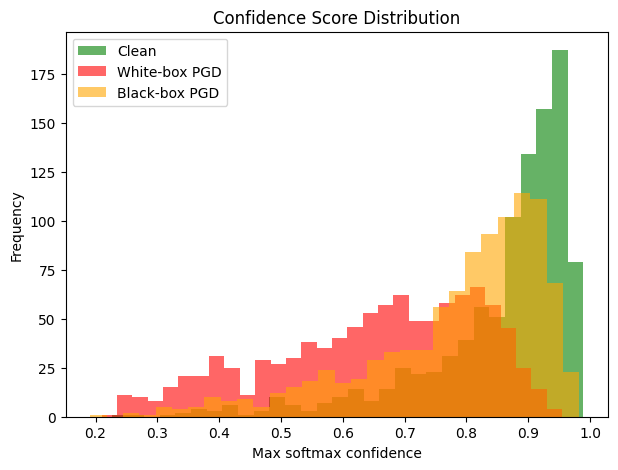

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.hist(conf_clean, bins=30, alpha=0.6, label="Clean", color='green')
plt.hist(conf_wb, bins=30, alpha=0.6, label="White-box PGD", color='red')
plt.hist(conf_bb, bins=30, alpha=0.6, label="Black-box PGD", color='orange')
plt.title("Confidence Score Distribution")
plt.xlabel("Max softmax confidence")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Identify vulnerable categories

In [33]:
from collections import defaultdict

def per_class_accuracy_np(y_true, y_pred):
    y_true_np = y_true.tondarray()
    y_pred_np = y_pred.tondarray()
    acc_per_class = {}
    classes = np.unique(y_true_np)
    for c in classes:
        idx = np.where(y_true_np == c)[0]
        correct = (y_pred_np[idx] == c).sum()
        acc_per_class[int(c)] = correct / len(idx)
    return acc_per_class

# Compute class-wise accuracy

In [34]:
y_clean_pred = poisoned_clf.predict(x_sub)
y_wb_pred = poisoned_clf.predict(adv_ds_pgd.X)
y_bb_pred = poisoned_clf.predict(adv_ds_bb.X)

acc_clean_pc = per_class_accuracy_np(y_sub, y_clean_pred)
acc_wb_pc    = per_class_accuracy_np(y_sub, y_wb_pred)
acc_bb_pc    = per_class_accuracy_np(y_sub, y_bb_pred)

# Print comparative results

In [35]:
print("Per-class accuracy (Clean vs White-box vs Black-box):")
for c in sorted(acc_clean_pc.keys()):
    print(f"Class {c}: Clean={acc_clean_pc[c]:.2f}, WB={acc_wb_pc[c]:.2f}, BB={acc_bb_pc[c]:.2f}")

Per-class accuracy (Clean vs White-box vs Black-box):
Class 0: Clean=0.99, WB=0.99, BB=0.99
Class 1: Clean=0.98, WB=0.98, BB=0.98
Class 2: Clean=0.98, WB=0.94, BB=0.97
Class 3: Clean=0.97, WB=0.89, BB=0.96
Class 4: Clean=0.99, WB=0.89, BB=0.99
Class 5: Clean=1.00, WB=0.95, BB=0.96
Class 6: Clean=0.98, WB=0.94, BB=0.97
Class 7: Clean=0.97, WB=0.93, BB=0.96
Class 8: Clean=0.98, WB=0.92, BB=0.98
Class 9: Clean=0.95, WB=0.86, BB=0.95


# Setup FGM evasion

In [36]:
epsilon = 0.1
fgm_attack = CFoolboxFGM(
    classifier=poisoned_clf,
    epsilons=epsilon,
    lb=0.0,
    ub=1.0
)

# Execute FGM attack

In [37]:
_, _, adv_ds_fgm, _ = fgm_attack.run(x_sub, y_sub)
y_adv_fgm_pred = poisoned_clf.predict(adv_ds_fgm.X)
acc_fgm = metric.performance_score(y_sub, y_adv_fgm_pred)
print("White-box FGM (L∞) accuracy:", acc_fgm)
print("ASR:", 1 - acc_fgm)

White-box FGM (L∞) accuracy: 0.979
ASR: 0.02100000000000002


# Evaluate surrogate robustness

In [38]:
acc_pgd_on_surrogate = metric.performance_score(
    y_sub, surrogate_clf.predict(adv_ds_pgd.X)
)

acc_fgm_on_surrogate = metric.performance_score(
    y_sub, surrogate_clf.predict(adv_ds_fgm.X)
)

print("Transferability (PGD -> surrogate):", acc_pgd_on_surrogate)
print("Transferability (FGM -> surrogate):", acc_fgm_on_surrogate)

Transferability (PGD -> surrogate): 0.906
Transferability (FGM -> surrogate): 0.956


# Generate security curve

Epsilon=0.00, Accuracy=0.980
Epsilon=0.05, Accuracy=0.980
Epsilon=0.10, Accuracy=0.979
Epsilon=0.20, Accuracy=0.975
Epsilon=0.30, Accuracy=0.971


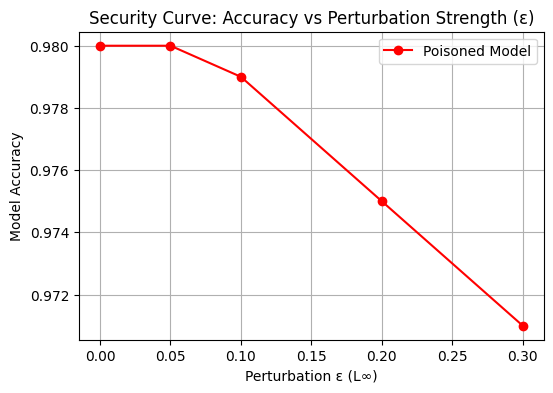

In [39]:
epsilons = [0.0, 0.05, 0.1, 0.2, 0.3]
acc_list = []

for eps in epsilons:
    fgm = CFoolboxFGM(
        classifier=poisoned_clf,
        epsilons=eps,
        lb=0.0,
        ub=1.0
    )
    _, _, adv_ds, _ = fgm.run(x_sub, y_sub)
    y_pred = poisoned_clf.predict(adv_ds.X)
    acc = CMetricAccuracy().performance_score(y_sub, y_pred)
    acc_list.append(acc)
    print(f"Epsilon={eps:.2f}, Accuracy={acc:.3f}")

plt.figure(figsize=(6,4))
plt.plot(epsilons, acc_list, marker='o', color='red', label='Poisoned Model')
plt.title("Security Curve: Accuracy vs Perturbation Strength (ε)")
plt.xlabel("Perturbation ε (L∞)")
plt.ylabel("Model Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Define poisoning ratios

In [40]:
poison_rates = [0.0, 0.05, 0.10, 0.15, 0.20]
acc_poison_curve = []

# Retrain contaminated models

In [41]:
for rate in poison_rates:
    ds_poisoned = tr_ds.deepcopy()
    n_samples = ds_poisoned.num_samples
    n_poison = int(rate * n_samples)
    idx = np.random.choice(n_samples, n_poison, replace=False)
    idx_carray = CArray(idx)
    
    orig_labels = ds_poisoned.Y[idx_carray].tondarray()
    new_labels = []
    for y in orig_labels:
        candidates = list(set(range(10)) - {int(y)})
        new_labels.append(np.random.choice(candidates))
    ds_poisoned.Y[idx_carray] = CArray(new_labels)
    
    model = SimpleCNN()
    clf_tmp = CClassifierPyTorch(
        model=model,
        loss=nn.CrossEntropyLoss(),
        optimizer=optim.Adam(model.parameters(), lr=0.001),
        input_shape=(1,28,28),
        epochs=3,
        batch_size=128,
        random_state=0
    )
    clf_tmp.fit(ds_poisoned.X, ds_poisoned.Y)
    
    y_pred = clf_tmp.predict(test_ds.X)
    acc = CMetricAccuracy().performance_score(test_ds.Y, y_pred)
    acc_poison_curve.append(acc)
    print(f"Poison rate={rate:.2f}, Test Accuracy={acc:.3f}")

Poison rate=0.00, Test Accuracy=0.982
Poison rate=0.05, Test Accuracy=0.983
Poison rate=0.10, Test Accuracy=0.982
Poison rate=0.15, Test Accuracy=0.982
Poison rate=0.20, Test Accuracy=0.980


# Visualize poisoning impact

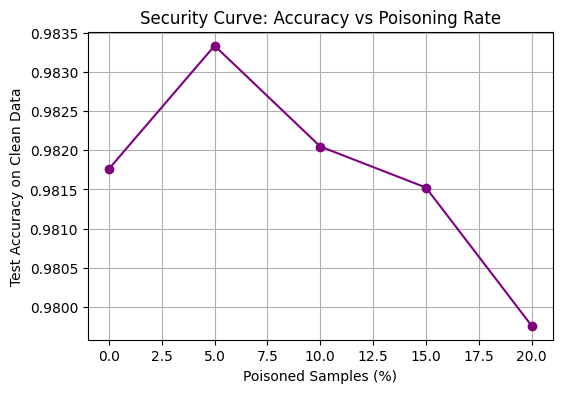

In [42]:
plt.figure(figsize=(6,4))
plt.plot([r*100 for r in poison_rates], acc_poison_curve, marker='o', color='purple')
plt.title("Security Curve: Accuracy vs Poisoning Rate")
plt.xlabel("Poisoned Samples (%)")
plt.ylabel("Test Accuracy on Clean Data")
plt.grid(True)
plt.show()

# Part 2

# Prepare training data for Isolation Forest

In [43]:
X_train_np = tr_ds.X.tondarray().reshape(tr_ds.num_samples, -1)
iso_forest = IsolationForest(contamination=0.1, random_state=0)
iso_forest.fit(X_train_np)

,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,0
,verbose,0
,warm_start,False


# Create sanitized dataset

In [44]:
pred = iso_forest.predict(X_train_np)
mask_clean = pred == 1

In [45]:
mask_carray = CArray(mask_clean)
X_sanitized = tr_ds.X[mask_carray, :]
Y_sanitized = tr_ds.Y[mask_carray]

print("Original train samples:", tr_ds.num_samples)
print("After sanitization:", X_sanitized.shape[0])

Original train samples: 39200
After sanitization: 35280


# Define CNN architecture with Dropout

In [46]:
class RobustCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64*5*5, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Train on sanitized data.

In [47]:
robust_model = RobustCNN()
robust_clf = CClassifierPyTorch(
    model=robust_model,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(robust_model.parameters(), lr=0.001),
    input_shape=(1,28,28),
    epochs=5,
    batch_size=128,
    random_state=0
)

In [48]:
robust_clf.fit(X_sanitized, Y_sanitized)

RobustCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

# Measure post-defense accuracy.

In [49]:
metric = CMetricAccuracy()
y_pred = robust_clf.predict(test_ds.X)
acc = metric.performance_score(test_ds.Y, y_pred)
print("Accuracy on test set after defense:", acc)

Accuracy on test set after defense: 0.9861904761904762


# Set attack hyperparameters

In [50]:
epsilon = 0.1
pgd_steps = 10
batch_size = 128
epochs = 5
subset_size = 1000

# Subset training data

In [51]:
np.random.seed(0)
subset_idx = np.random.choice(X_sanitized.shape[0], subset_size, replace=False)
X_train_sub = X_sanitized[CArray(subset_idx), :]
Y_train_sub = Y_sanitized[CArray(subset_idx)]

# Retrain for adversarial robustness

In [52]:
pgd_attack = CFoolboxPGDLinf(
    classifier=robust_clf,
    epsilons=epsilon,
    steps=pgd_steps,
    lb=0.0,
    ub=1.0,
    random_start=True
)
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    idx_perm = np.random.permutation(subset_size)
    
    X_shuf = X_train_sub[CArray(idx_perm), :]
    Y_shuf = Y_train_sub[CArray(idx_perm)]
    _, _, adv_ds, _ = pgd_attack.run(X_shuf, Y_shuf)

    X_combined = CArray.concatenate(X_shuf, adv_ds.X)
    Y_combined = CArray.concatenate(Y_shuf, adv_ds.Y)
    X_combined = CArray(X_combined.tondarray().reshape(-1, 1, 28, 28))

    robust_clf.fit(X_combined, Y_combined)
    print(f"Epoch {epoch+1} adversarial training done.")


Epoch 1/5
Epoch 1 adversarial training done.

Epoch 2/5
Epoch 2 adversarial training done.

Epoch 3/5
Epoch 3 adversarial training done.

Epoch 4/5
Epoch 4 adversarial training done.

Epoch 5/5
Epoch 5 adversarial training done.


# Validate post-training performance

In [53]:
metric = CMetricAccuracy()
y_pred_clean = robust_clf.predict(test_ds.X)
acc_clean = metric.performance_score(test_ds.Y, y_pred_clean)
print("\nAccuracy on clean test set after adversarial training:", acc_clean)


Accuracy on clean test set after adversarial training: 0.11271428571428571


# Randomized smoothing techniques

In [54]:
def randomized_smoothing_predict(model, X, n_samples=10, sigma=0.1, device='cpu'):
    X_tensor = torch.tensor(X.tondarray(), dtype=torch.float32, device=device)
    X_tensor = X_tensor.view(-1, 1, 28, 28)

    model.model.to(device)
    model.model.eval()
    
    preds = []
    for i in range(n_samples):
        noise = torch.randn_like(X_tensor) * sigma
        with torch.no_grad():
            logits = model.model(X_tensor + noise)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    
    preds = np.array(preds)
    final_preds = []
    for j in range(X_tensor.shape[0]):
        counts = np.bincount(preds[:, j])
        final_preds.append(np.argmax(counts))
    
    return np.array(final_preds)

# Execute smoothing inference

In [55]:
y_pred_rs = randomized_smoothing_predict(robust_clf, test_ds.X, n_samples=10, sigma=0.1)
acc_rs = (y_pred_rs == test_ds.Y.tondarray()).mean()
print("Accuracy under Randomized Smoothing:", acc_rs)

Accuracy under Randomized Smoothing: 0.11261904761904762


# Assess accuracy trade-offs

In [ ]:
y_pred_clean_before = poisoned_clf.predict(test_ds.X)
acc_before = metric.performance_score(test_ds.Y, y_pred_clean_before)

y_pred_clean_after = robust_clf.predict(test_ds.X)
acc_after = metric.performance_score(test_ds.Y, y_pred_clean_after)

print("Clean test accuracy BEFORE defense:", acc_before)
print("Clean test accuracy AFTER defense:", acc_after)

Clean test accuracy BEFORE defense: 0.9847619047619047
Clean test accuracy AFTER defense: 0.11271428571428571


# Sample test subset

In [57]:
subset_attack_size = 1000
subset_idx = np.random.choice(test_ds.num_samples, subset_attack_size, replace=False)
X_test_sub = test_ds.X[CArray(subset_idx), :]
Y_test_sub = test_ds.Y[CArray(subset_idx)]

# Compare pre-defense ASR

In [ ]:
start_time = time.time()
pgd_before = CFoolboxPGDLinf(classifier=poisoned_clf, epsilons=epsilon, steps=pgd_steps)
_, _, adv_ds_before, _ = pgd_before.run(X_test_sub, Y_test_sub)
y_pred_adv_before = poisoned_clf.predict(adv_ds_before.X)
asr_before = 1 - metric.performance_score(Y_test_sub, y_pred_adv_before)
time_before = time.time() - start_time

# Compare post-defense ASR

In [59]:
start_time = time.time()
pgd_after = CFoolboxPGDLinf(classifier=robust_clf, epsilons=epsilon, steps=pgd_steps)
_, _, adv_ds_after, _ = pgd_after.run(X_test_sub, Y_test_sub)
y_pred_adv_after = robust_clf.predict(adv_ds_after.X)
asr_after = 1 - metric.performance_score(Y_test_sub, y_pred_adv_after)
time_after = time.time() - start_time

# Compare Attack Success Rate

In [60]:
print("\nAttack Success Rate BEFORE defense:", asr_before)
print("Attack Success Rate AFTER defense:", asr_after)
print("\nComputational overhead (seconds):")
print(f"PGD attack before defense: {time_before:.2f}s")
print(f"PGD attack after defense: {time_after:.2f}s")


Attack Success Rate BEFORE defense: 0.041000000000000036
Attack Success Rate AFTER defense: 0.886

Computational overhead (seconds):
PGD attack before defense: 209.28s
PGD attack after defense: 203.85s


# Apply smoothing to test subset

In [61]:
y_pred_rs = randomized_smoothing_predict(robust_clf, X_test_sub, n_samples=10, sigma=0.1)
acc_rs = (y_pred_rs == Y_test_sub.tondarray()).mean()
print("\nAccuracy under Randomized Smoothing (subset):", acc_rs)


Accuracy under Randomized Smoothing (subset): 0.115


# Final subset extraction

In [62]:
subset_size = 1000
subset_idx = np.random.choice(test_ds.num_samples, subset_size, replace=False)
X_subset = test_ds.X[CArray(subset_idx), :].tondarray()
Y_subset = test_ds.Y[CArray(subset_idx)].tondarray()

# Prepare data for visualization

In [63]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_subset)

# Prepare for error analysis

In [64]:
y_pred_before = poisoned_clf.predict(CArray(X_subset)).tondarray()
y_pred_after = robust_clf.predict(CArray(X_subset)).tondarray()

# Visualize classification clusters

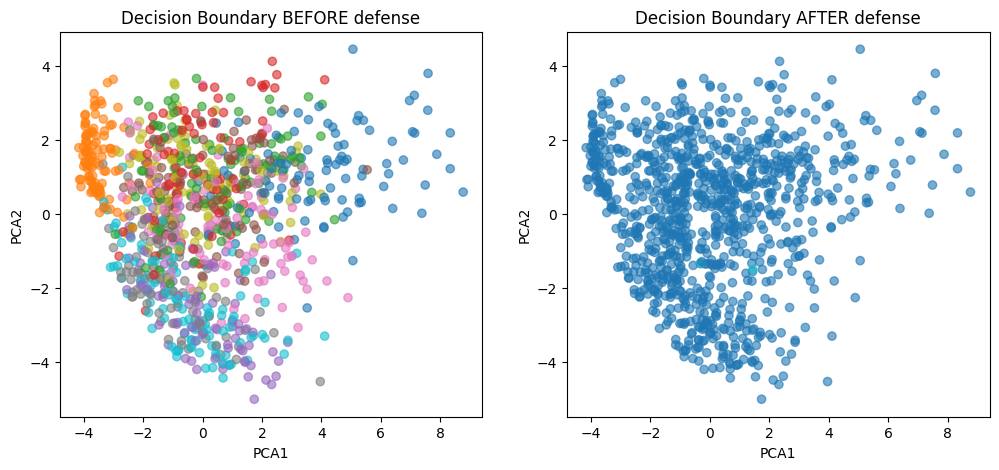

In [65]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_before, cmap='tab10', alpha=0.6)
plt.title("Decision Boundary BEFORE defense")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_after, cmap='tab10', alpha=0.6)
plt.title("Decision Boundary AFTER defense")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

# Conduct gradient sensitivity analysis

In [66]:
def gradient_sensitivity(model, X):
    # Chuyển sang torch tensor
    X_tensor = torch.tensor(X.tondarray(), dtype=torch.float32)
    
    model.model.eval()
    grads = []

    for i in range(X_tensor.shape[0]):
        x_i = X_tensor[i:i+1].view(1, 1, 28, 28)
        x_i.requires_grad = True

        model.model.zero_grad()
        output = model.model(x_i)
        loss = output.max()
        loss.backward()
        
        grads.append(x_i.grad.detach().numpy())
    
    grads = np.array(grads)
    return grads


In [67]:
X_grad_subset = test_ds.X[CArray(subset_idx), :]
grads_before = gradient_sensitivity(poisoned_clf, X_grad_subset)
grads_after = gradient_sensitivity(robust_clf, X_grad_subset)

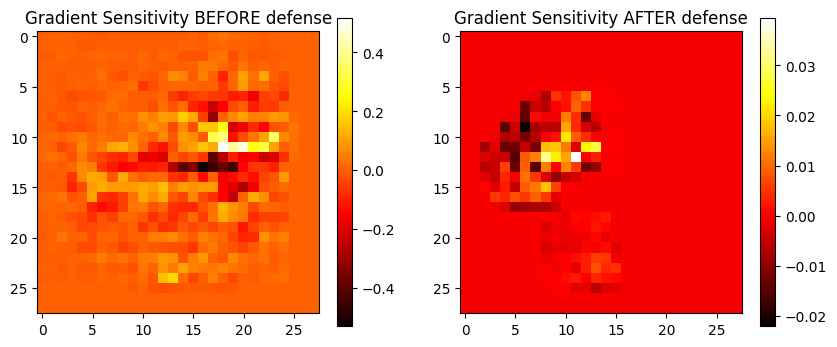

In [68]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(grads_before[0].reshape(28,28), cmap='hot')
plt.title("Gradient Sensitivity BEFORE defense")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(grads_after[0].reshape(28,28), cmap='hot')
plt.title("Gradient Sensitivity AFTER defense")
plt.colorbar()
plt.show()